# Single-power run — chunk (time-segment) comparison

One configuration (fixed filter, polarisation **and** pump power), acquired in **chunks** —
successive time segments of the same run. This notebook overlays every chunk so the temporal
stability / reproducibility of the photon statistics within the acquisition is read off
directly.

It compares, across chunks:
* the auto/cross $g^{(2)}(0)$,
* the Cauchy–Schwarz $R$ parameter,
* the coherence (correlation-histogram) shapes.

> For a power *scan* (many powers) use `powerscan_*.ipynb` instead.

In [1]:
import os
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath('../../')
if not os.path.isdir(os.path.join(project_root, 'src')):
    project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.hbt_core import HBTMeasurement
from src.hbt_visu import GridVisualizer

## 1. Discover the chunks

Point `RUN_DIR` at the single-power run folder. Every `*chunk*.pkl` is picked up and the chunks
are sorted by their index parsed from the filename (`..._chunkN.pkl`). All chunks share the same
filter / polarisation / power, so they are labelled by their chunk number instead of the
(identical) configuration tag.

A sanity check warns if the chunks are **not** all at the same power.

In [2]:
RUN_DIR = Path(project_root) / "data/Jun17/SinglePower_GaAs100_700-40_P1"

def _chunk_idx(p):
    m = re.search(r'chunk(\d+)', p.name)
    return int(m.group(1)) if m else -1

run_files = sorted(RUN_DIR.glob("*chunk*.pkl"), key=_chunk_idx)
assert run_files, f"No chunk files found under {RUN_DIR}"

runs = [HBTMeasurement(f) for f in run_files]
labels = [f"chunk {_chunk_idx(f)}" for f in run_files]

ref = runs[0]
print(f"Discovered {len(runs)} chunk(s) in {RUN_DIR}:")
print(f"  {ref.acquisition_summary()}")
print(f"  {ref.acquisition_details()}")
print(f"  physical histograms: {all(r.has_physical_histograms for r in runs)}")
print(f"  chunks: {labels}")

powers = {r.power_mw for r in runs if r.power_mw is not None}
if len(powers) > 1:
    print(f"\n[!] WARNING: chunks span several powers {sorted(powers)} mW — expected a single power.")

Discovered 2 chunk(s) in /Users/simon.wtmn/Desktop/Quantum_SHHG/data/Jun17/SinglePower_GaAs100_700-40_P1:
  Sample: GaAs100_100um_P1_700_40_cover  |  $\lambda_L = 2100$ nm  |  $P = 40$ mW  |  $f_{rep} = 18.66$ MHz
  bin $= 100$ ps  |  coinc. window $= 25$ ns  |  $T_{acq} = 120$ s  |  stage $= 19.5$  |  2026-06-17
  physical histograms: True
  chunks: ['chunk 0', 'chunk 1']


## 2. Summary table

Physical $g^{(2)}(0)$ (the artifact-free **direct** method) for the three auto-correlations and
the three cross pairs, plus the Cauchy–Schwarz $R$ for each harmonic pair. One row per chunk —
the quickest read of the chunk-to-chunk stability.

In [3]:
def auto(r, h):     return r.compute_g2_direct(r.get_ch(f"H{h}T"), r.get_ch(f"H{h}R"))
def cross(r, a, b): return r.compute_g2_direct(r.get_ch(f"H{a}T"), r.get_ch(f"H{b}T"))
def Rpar(r, a, b):  return r.compute_R_parameter(cross(r, a, b), auto(r, a), auto(r, b))

cols = ["g2_33", "g2_44", "g2_55", "g2_34", "g2_35", "g2_45", "R_34", "R_35", "R_45"]
hdr = f"{'chunk':12s}" + "".join(f"{c:>9s}" for c in cols)
print(hdr); print("-" * len(hdr))

summary = {}
for r, lab in zip(runs, labels):
    vals = [auto(r, 3), auto(r, 4), auto(r, 5),
            cross(r, 3, 4), cross(r, 3, 5), cross(r, 4, 5),
            Rpar(r, 3, 4), Rpar(r, 3, 5), Rpar(r, 4, 5)]
    summary[lab] = dict(zip(cols, vals))
    print(f"{lab:12s}" + "".join(f"{v:9.3f}" for v in vals))

if len(runs) > 1:
    print("-" * len(hdr))
    arr = np.array([[summary[l][c] for c in cols] for l in labels], float)
    print(f"{'mean':12s}" + "".join(f"{v:9.3f}" for v in np.nanmean(arr, axis=0)))
    print(f"{'std':12s}" + "".join(f"{v:9.3f}" for v in np.nanstd(arr, axis=0)))

chunk           g2_33    g2_44    g2_55    g2_34    g2_35    g2_45     R_34     R_35     R_45
---------------------------------------------------------------------------------------------
chunk 0         1.049      nan    1.116      nan    1.070      nan      nan    0.978      nan
chunk 1         1.049      nan    1.113      nan    1.072      nan      nan    0.985      nan
---------------------------------------------------------------------------------------------
mean            1.049      nan    1.114      nan    1.071      nan      nan    0.982      nan
std             0.000      nan    0.001      nan    0.001      nan      nan    0.004      nan


/var/folders/xy/f8rjrkmd0l31wz0k79x01tqr0000gn/T/ipykernel_24910/1933668838.py:20: RuntimeWarning: Mean of empty slice
  print(f"{'mean':12s}" + "".join(f"{v:9.3f}" for v in np.nanmean(arr, axis=0)))
/Users/simon.wtmn/Desktop/Quantum_SHHG/SHHGvenv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 3. Bar comparison of $g^{(2)}$ and $R$

The same table as grouped bars, one colour per chunk — the visual companion to the numbers
above. Left: auto/cross $g^{(2)}(0)$ (dashed line = uncorrelated, $g^{(2)}=1$). Right:
Cauchy–Schwarz $R$ (dashed line = classical bound $R=1$). Flat bars across chunks = a stable run.

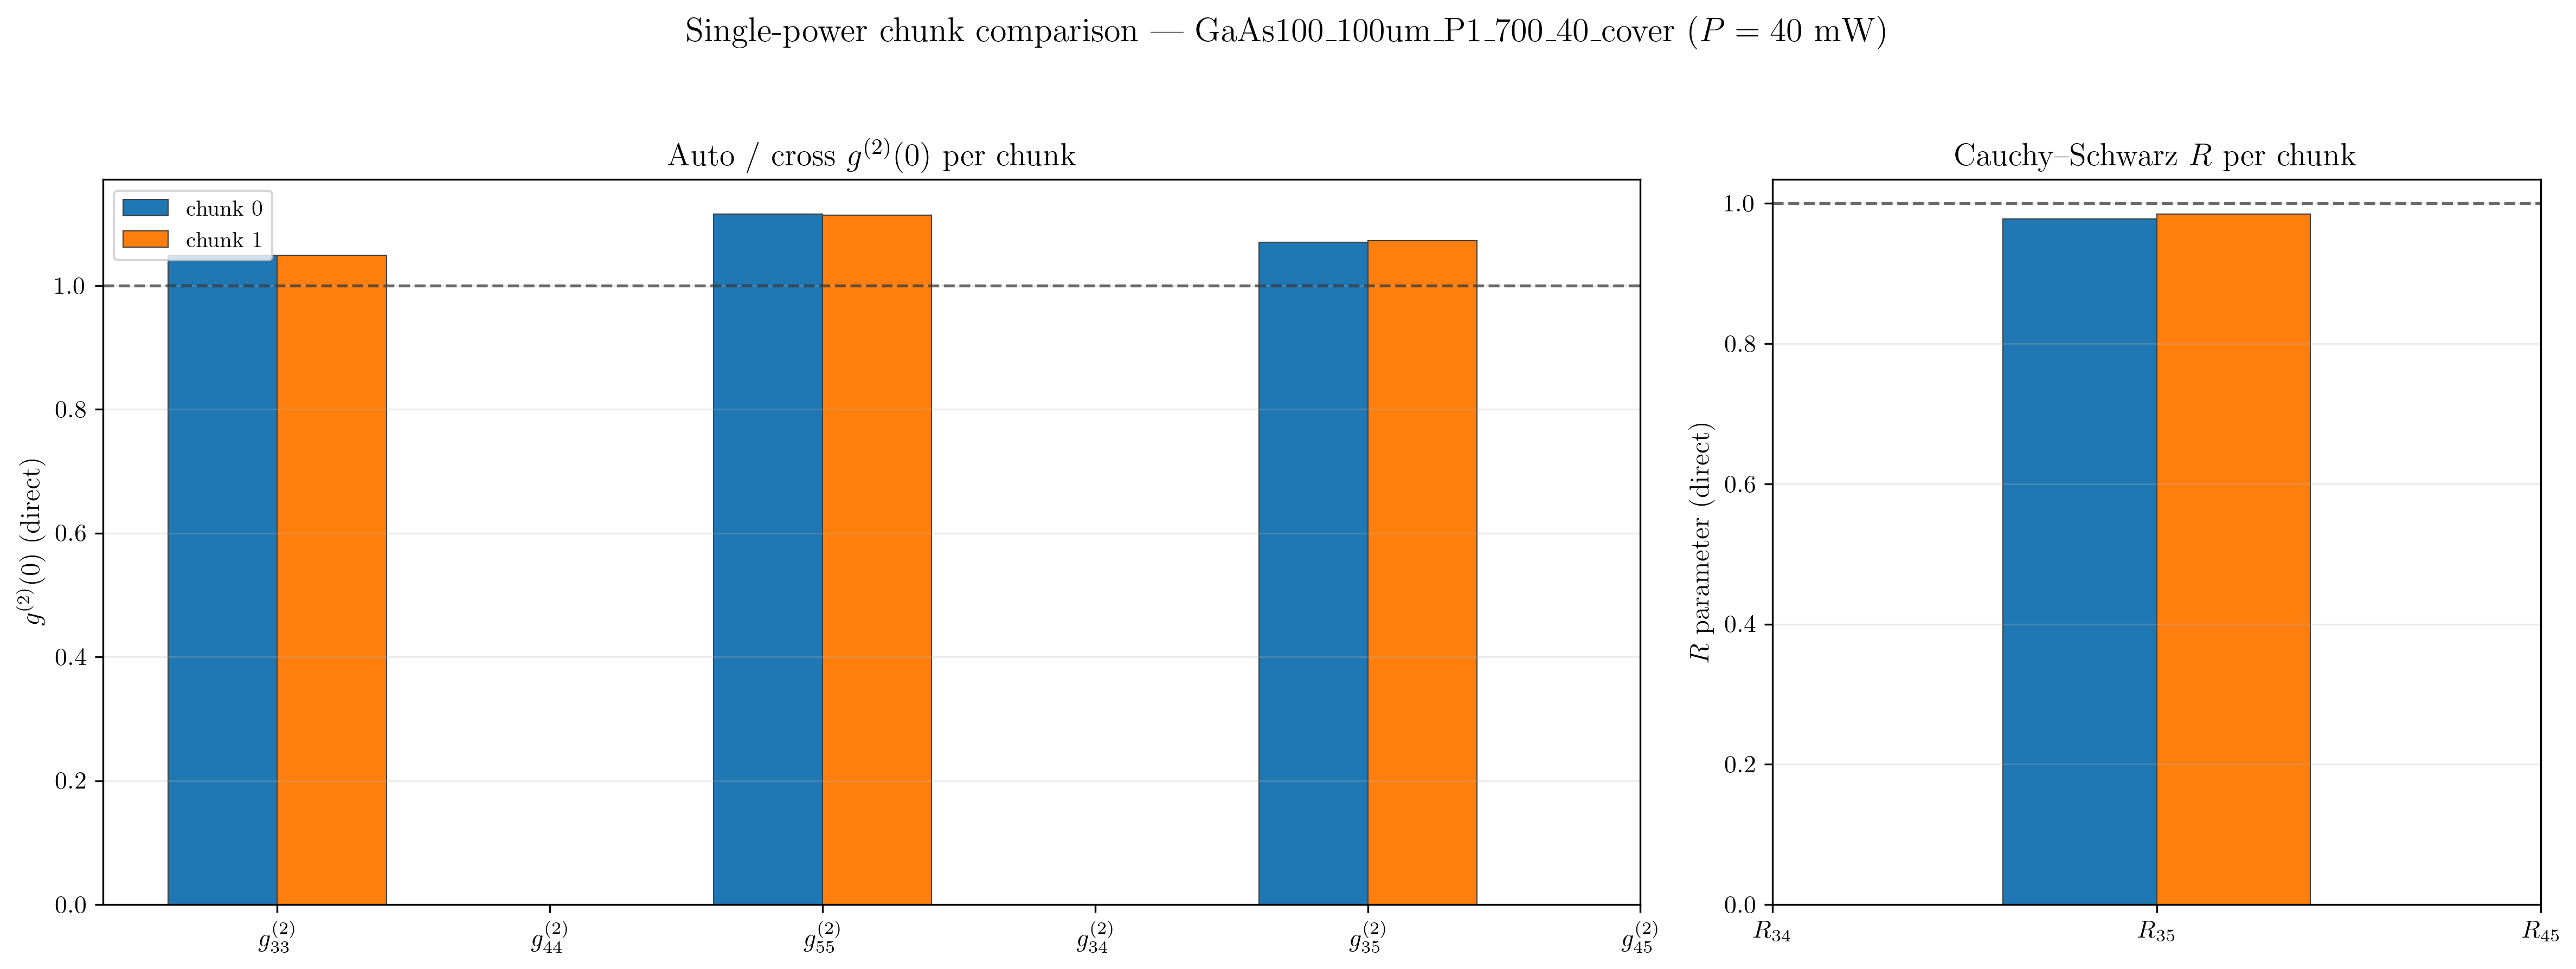

In [4]:
g2_cols = ["g2_33", "g2_44", "g2_55", "g2_34", "g2_35", "g2_45"]
r_cols = ["R_34", "R_35", "R_45"]
g2_tick = [r"$g^{(2)}_{33}$", r"$g^{(2)}_{44}$", r"$g^{(2)}_{55}$",
           r"$g^{(2)}_{34}$", r"$g^{(2)}_{35}$", r"$g^{(2)}_{45}$"]
r_tick = [r"$R_{34}$", r"$R_{35}$", r"$R_{45}$"]

run_colors = GridVisualizer(runs, labels=labels, comparison_variable="Chunk").run_colors
n = len(runs)

fig, (axg, axr) = plt.subplots(1, 2, figsize=(16, 6), dpi=300,
                               gridspec_kw={'width_ratios': [2, 1]})
for ax, names, ticks, refline in [(axg, g2_cols, g2_tick, 1.0), (axr, r_cols, r_tick, 1.0)]:
    x = np.arange(len(names))
    w = 0.8 / n
    for i, lab in enumerate(labels):
        y = [summary[lab][c] for c in names]
        ax.bar(x + (i - (n - 1) / 2) * w, y, width=w, color=run_colors[i],
               label=lab, edgecolor='0.25', linewidth=0.5)
    ax.axhline(refline, color='#313131', ls='--', lw=1.3, alpha=0.7)
    ax.set_xticks(x); ax.set_xticklabels(ticks)
    ax.grid(True, axis='y', alpha=0.25)
axg.set_ylabel(r"$g^{(2)}(0)$ (direct)")
axr.set_ylabel(r"$R$ parameter (direct)")
axg.set_title(r"Auto / cross $g^{(2)}(0)$ per chunk")
axr.set_title(r"Cauchy–Schwarz $R$ per chunk")
axg.legend(loc='best', fontsize=10, ncol=max(1, n // 3))
fig.suptitle(rf"Single-power chunk comparison — {ref.material}  ($P = {ref.power_mw:g}$ mW)",
             fontsize=15, y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 4. Overlaid sweeps — $g^{(2)}$ and $R$ vs integration window

Every chunk overlaid on the same $5\times3$ ($g^{(2)}$) and $4\times3$ ($R$) matrices, swept over
the integration window $\tau_{in}$. Each curve is one chunk; a plateau across $\tau_{in}$ means
the value is robust, and chunks landing on top of each other means the run is stable. The
`delay` (peak-area) method is used — physical here since the runs carry per-detector histograms.

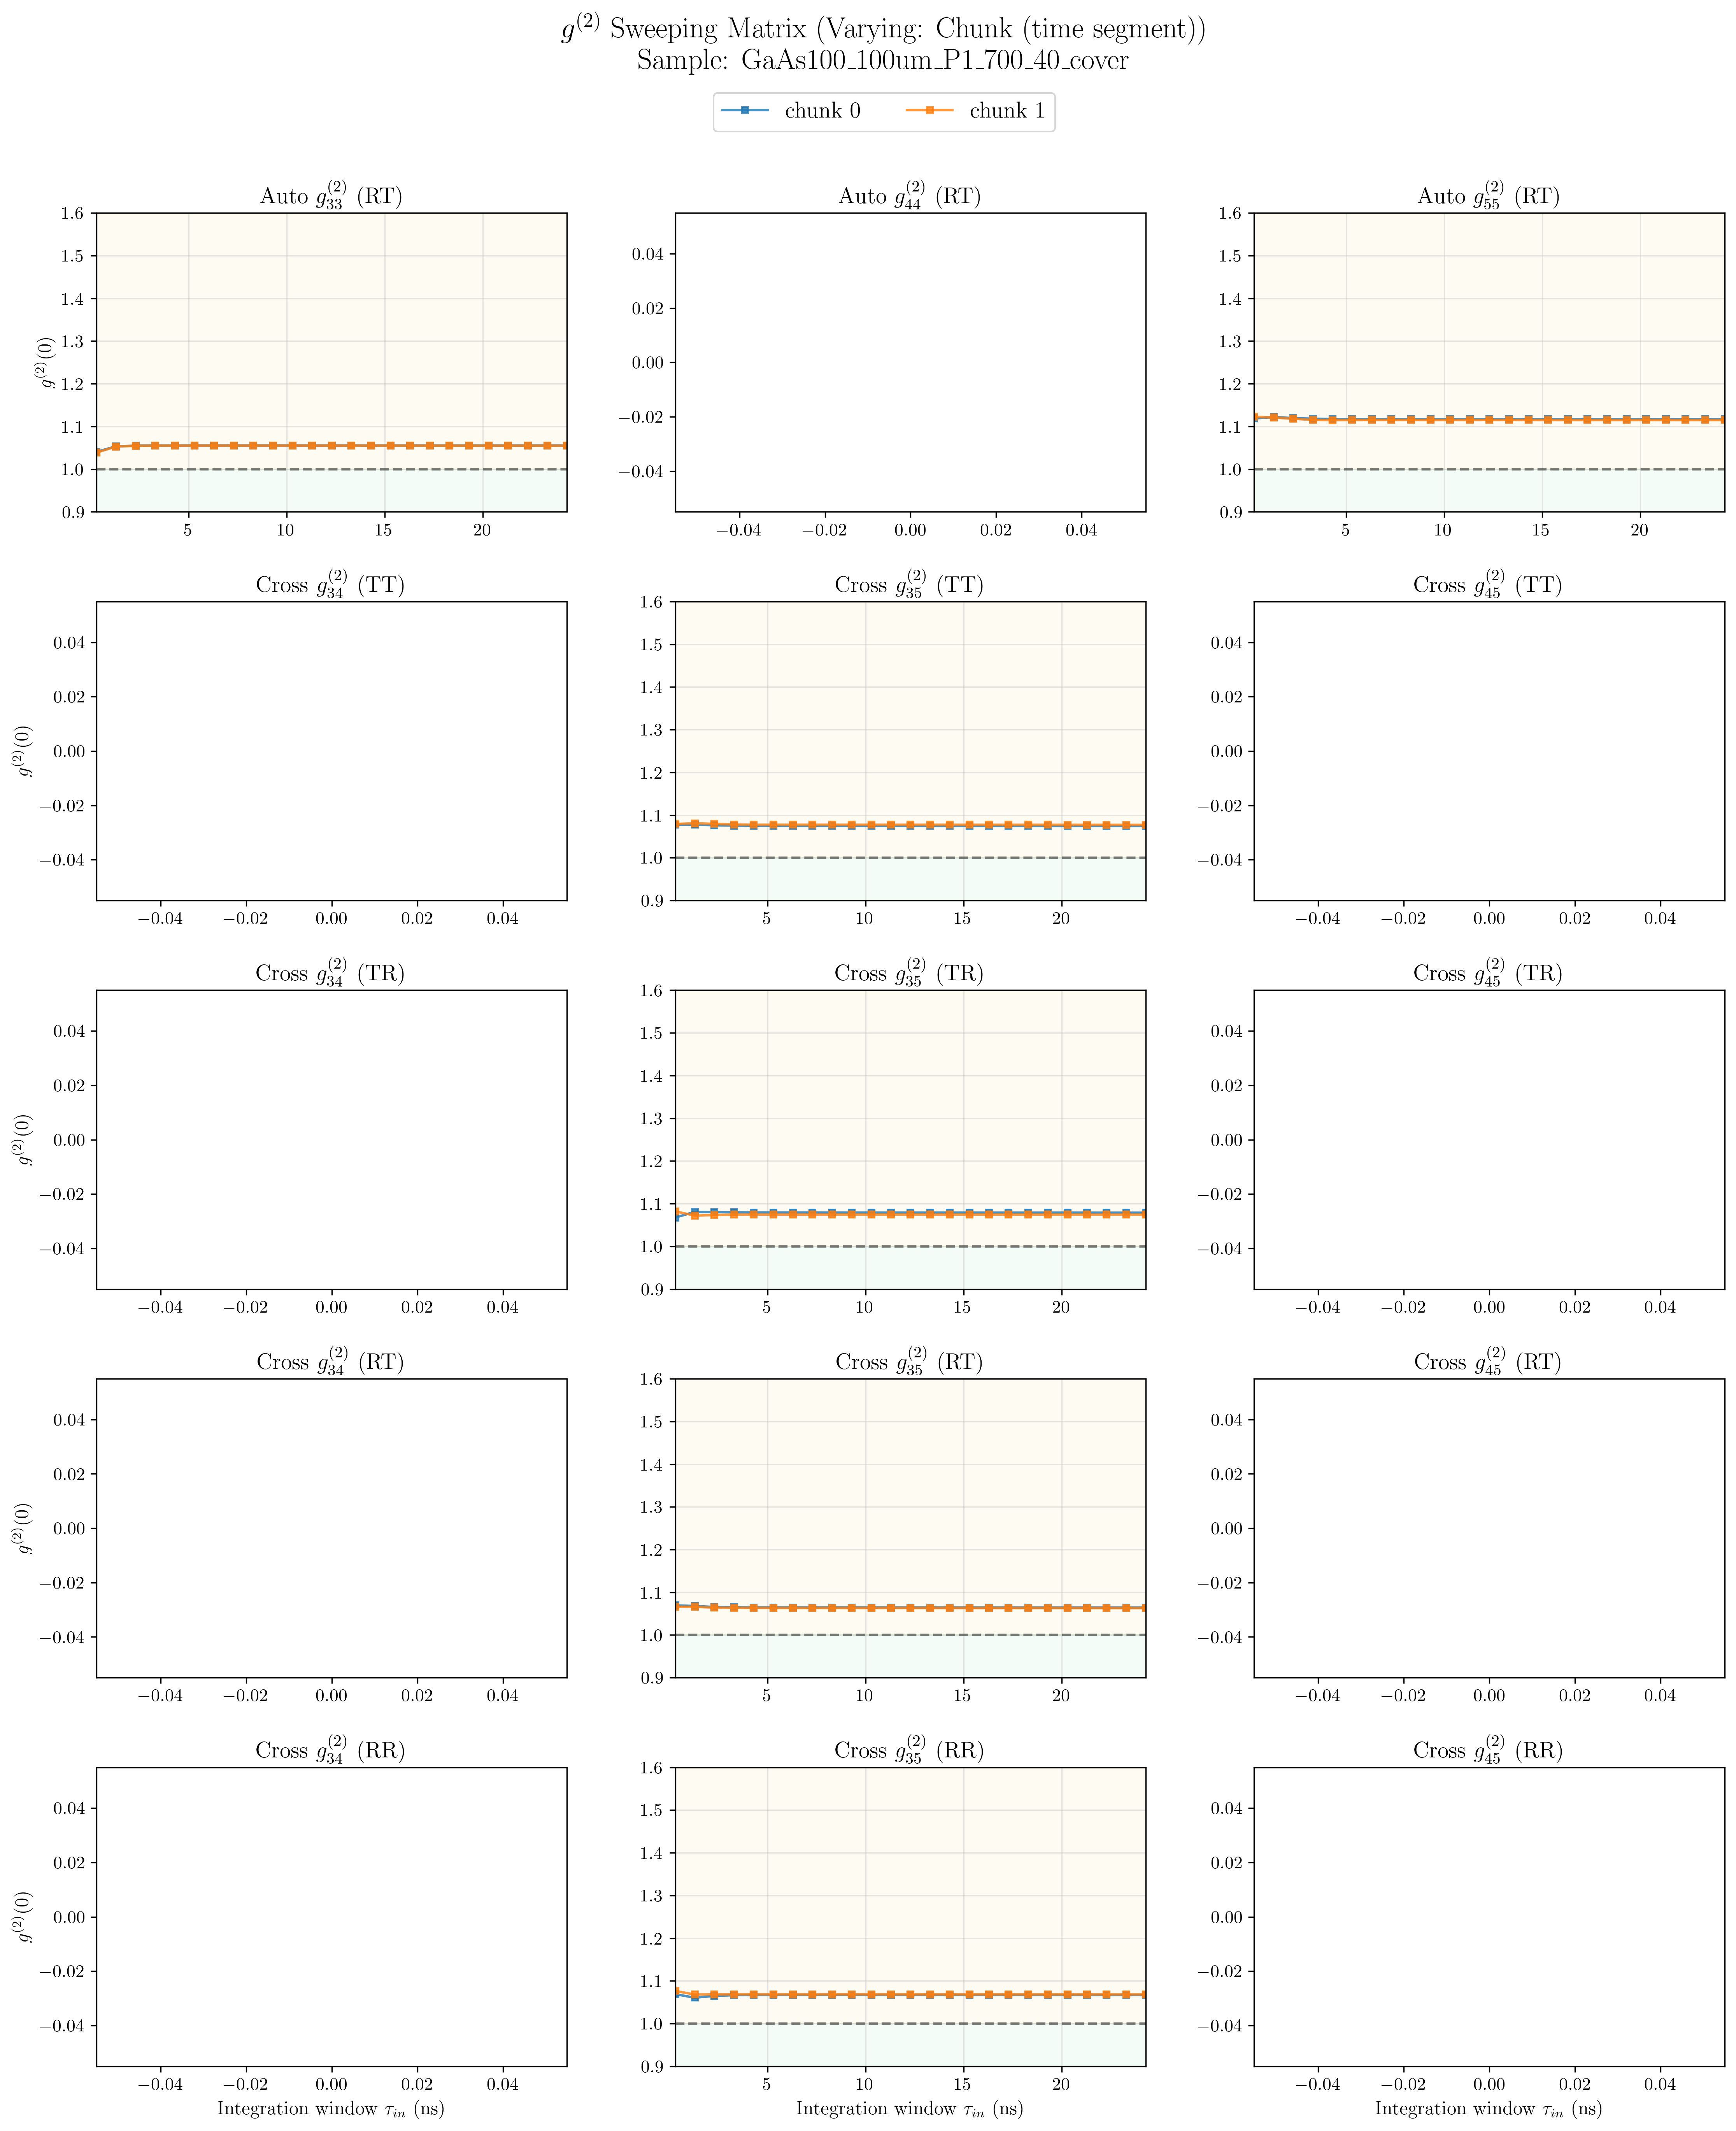

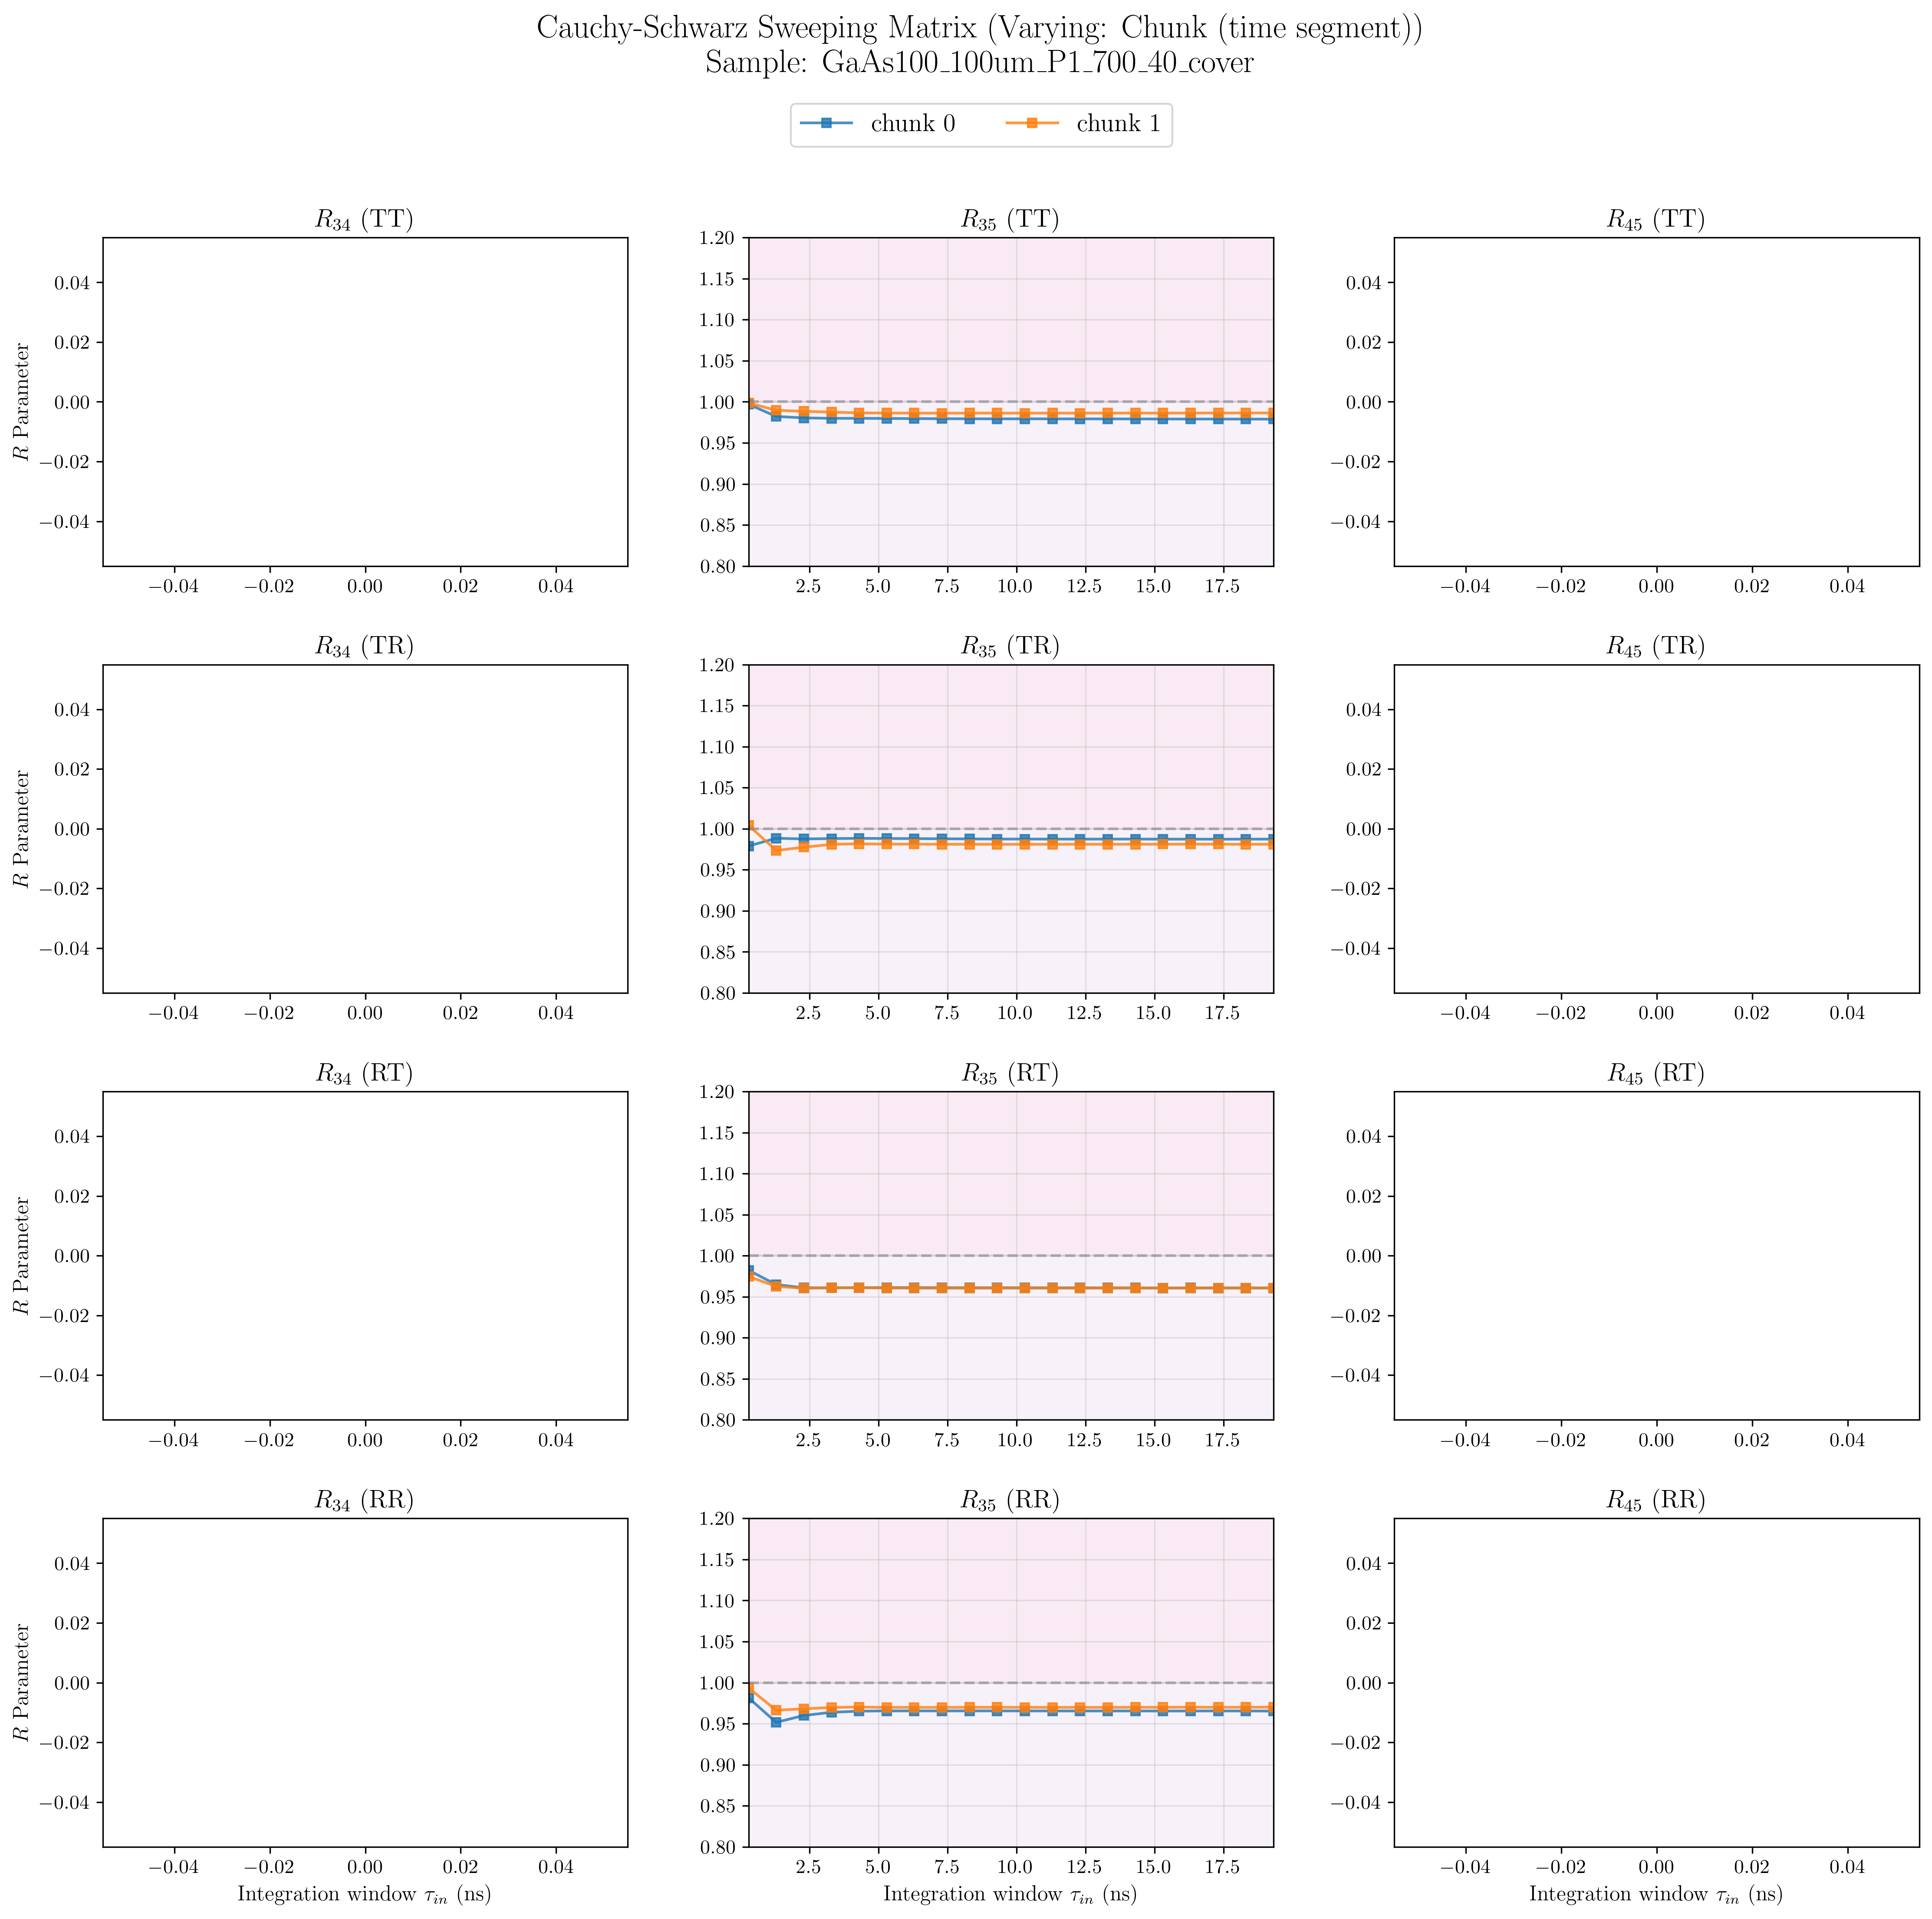

(<Figure size 5400x4800 with 12 Axes>,
 array([[<Axes: title={'center': '$R_{34}$ (TT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TT)'}>,
         <Axes: title={'center': '$R_{45}$ (TT)'}>],
        [<Axes: title={'center': '$R_{34}$ (TR)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TR)'}>,
         <Axes: title={'center': '$R_{45}$ (TR)'}>],
        [<Axes: title={'center': '$R_{34}$ (RT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RT)'}>,
         <Axes: title={'center': '$R_{45}$ (RT)'}>],
        [<Axes: title={'center': '$R_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)', ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>,
         <Axes: title={'center': '$R_{45}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>]],
       dtype=object))

In [5]:
comparator = GridVisualizer(runs, labels=labels, comparison_variable="Chunk (time segment)")

comparator.plot_g2(methods=['delay'], tau_min=0.3, tau_max=25, step=1.0)
comparator.plot_R(methods=['delay'], tau_min=0.3, tau_max=20, step=1.0)

## 5. Coherence shapes

The correlation histograms overlaid, peak-normalised so the *shapes* are directly comparable
across chunks. The shaded band marks the integration window.

In [6]:
# comparator.plot_coherence(time_window_ns=5.0, xlim=120, integration_window_ns=10.0)